In [1]:

!pip install sentence-transformers 
!pip install requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 9.2 MB/s eta 0:00:00
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 4.2 MB/s eta 0:00:00
  Using cached certifi-2026.6.17-py3-none-any.whl.metadata (2.5 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 765.1/765.1 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 64.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 62.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 56.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.6/676.6 kB

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import sklearn
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer




/Users/tisya_elan/Library/Mobile Documents/com~apple~CloudDocs/Workspace/Projects/film_recommendation_system/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub
path=kagglehub.dataset_download("rosemeenshaikh/top-10000-tmdbs-highest-rated-movies")

### Data Preprocessing

In [3]:
df=pd.read_csv(os.path.join(path,"top_rated_movies.csv"))

In [4]:
df.head()

,adult,id,original_language,original_title,overview,popularity,release_date,title,vote_average,vote_count
0,False,278,en,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,46.3708,1994-09-23,The Shawshank Redemption,8.718,30171
1,False,238,en,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",42.0006,1972-03-14,The Godfather,8.686,22787
2,False,240,en,The Godfather Part II,In the continuing saga of the Corleone crime f...,26.8671,1974-12-20,The Godfather Part II,8.571,13812
3,False,424,en,Schindler's List,The true story of how businessman Oskar Schind...,24.2944,1993-12-15,Schindler's List,8.567,17341
4,False,389,en,12 Angry Men,The defense and the prosecution have rested an...,19.4971,1957-04-10,12 Angry Men,8.559,9908


In [5]:
df.shape

(10000, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adult              10000 non-null  bool   
 1   id                 10000 non-null  int64  
 2   original_language  10000 non-null  str    
 3   original_title     10000 non-null  str    
 4   overview           9998 non-null   str    
 5   popularity         10000 non-null  float64
 6   release_date       9997 non-null   str    
 7   title              10000 non-null  str    
 8   vote_average       10000 non-null  float64
 9   vote_count         10000 non-null  int64  
dtypes: bool(1), float64(2), int64(2), str(5)
memory usage: 713.0 KB


In [7]:
df.isna().sum()

adult                0
id                   0
original_language    0
original_title       0
overview             2
popularity           0
release_date         3
title                0
vote_average         0
vote_count           0
dtype: int64

In [8]:
# inspect na vals 
df[df.isna().any(axis=1)]

,adult,id,original_language,original_title,overview,popularity,release_date,title,vote_average,vote_count
5480,False,733668,hy,Return,Eyüp decides to cross mount Ararat looking for...,0.1126,NaN,Return,6.6,424
5733,False,1198870,en,Return,A girl is at school. Suddenly it's as if she c...,0.1364,NaN,Return,6.6,443
6674,False,670355,en,Return,NaN,0.0524,NaN,Return,6.4,644
6737,False,1045781,tr,Ret,NaN,0.1613,2015-07-10,Ret,6.4,325


In [9]:
# impute my own vals from google for id 1045781

df.loc[df["id"]==1045781,"overview"]="Ottoman Empire – The times of World War I.Salim, who doesn't want to go into the army, tries to deceive the officers by pretending to be hearing impaired."

In [10]:
#ids 733668,1198870,670355 can be dropped since no more information can be found online about the film "Return"
df.dropna(inplace=True)

In [11]:
# insepect duplicates first
dupes=df[df.duplicated(keep=False)]
dupes


,adult,id,original_language,original_title,overview,popularity,release_date,title,vote_average,vote_count
3899,False,520758,en,Chicken Run: Dawn of the Nugget,A band of fearless chickens flock together to ...,4.9405,2023-12-08,Chicken Run: Dawn of the Nugget,6.900,875
3900,False,520758,en,Chicken Run: Dawn of the Nugget,A band of fearless chickens flock together to ...,4.9405,2023-12-08,Chicken Run: Dawn of the Nugget,6.900,875
4439,False,86838,en,Seven Psychopaths,A struggling screenwriter inadvertently become...,4.5313,2012-10-12,Seven Psychopaths,6.824,4245
4440,False,86838,en,Seven Psychopaths,A struggling screenwriter inadvertently become...,4.5313,2012-10-12,Seven Psychopaths,6.824,4245
4839,False,1088514,es,La habitación de al lado,Ingrid and Martha were close friends in their ...,3.3309,2024-10-07,The Room Next Door,6.747,674
4840,False,1088514,es,La habitación de al lado,Ingrid and Martha were close friends in their ...,3.3309,2024-10-07,The Room Next Door,6.747,674
5539,False,9463,ja,バンパイアハンターD,In a far-future time ruled by the supernatural...,4.7269,1985-12-21,Vampire Hunter D,6.600,530
5540,False,9463,ja,バンパイアハンターD,In a far-future time ruled by the supernatural...,4.7269,1985-12-21,Vampire Hunter D,6.600,530
6119,False,301365,en,The Neon Demon,When aspiring model Jesse moves to Los Angeles...,4.9868,2016-06-08,The Neon Demon,6.500,3919
6120,False,301365,en,The Neon Demon,When aspiring model Jesse moves to Los Angeles...,4.9868,2016-06-08,The Neon Demon,6.500,3919


In [12]:
# drop duplicates

df.drop_duplicates(inplace=True)

In [13]:
# create release year col

df['release_date']=pd.to_datetime(df["release_date"],format='%Y-%m-%d')
df["release_year"]=df["release_date"].dt.year

In [14]:
# weighted rating imdb formula

m=np.percentile(df["vote_count"], 95)
C=df["vote_average"].mean()

v=df["vote_count"]
R=df["vote_average"]

df["weighted_rating"] =(
    (v/(v+m))*R +
    (m/(v+m))*C)
    


In [15]:
#text preprocessing
df["overview"]=(df["overview"].fillna("").str.lower().str.replace(r"[^a-zA-Z\s]","",regex=True))#removes punctuation

In [16]:
# handle duplicate movie titles -noticed when building reco function for tf-idf 
# keep title with highes vote_count as its the most well known one

df=(df.sort_values("vote_count",ascending=False).drop_duplicates(subset="title",keep="first").reset_index(drop=True))

In [17]:
#explort cleaned df to data folder
# use relative path since i dont have to change it if i push it to github or someone else downlaods

project_root=Path.cwd().parent

data_path=project_root/"data"/"tmdb_movies_cleaned.csv"

df.to_csv(data_path,index=False)

## Exploratory Data Analysis




- ratings distribution
- top 100 films based on vote average
  

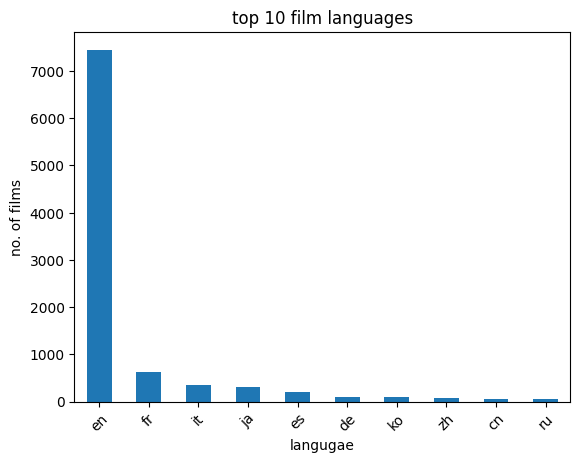

In [ ]:
#  find distribution of films by languages


top_lang=df["original_language"].value_counts().head(10)

top_lang.plot(kind="bar")
plt.title("top 10 film languages")
plt.xlabel("langugae")
plt.ylabel("no. of films")
plt.xticks(rotation=45)
plt.show()

In [23]:
lang_breakdown=df['original_language'].value_counts().reset_index(name="counts")

lang_breakdown["percent_breakdown"]=(lang_breakdown["counts"]/lang_breakdown["counts"].sum()*100).round(2)

lang_breakdown.reset_index(drop=True,inplace=True)
lang_breakdown


,original_language,counts,percent_breakdown
0,en,7455,77.58
1,fr,632,6.58
2,it,348,3.62
3,ja,305,3.17
4,es,194,2.02
5,de,103,1.07
6,ko,94,0.98
7,zh,67,0.70
8,cn,64,0.67
9,ru,52,0.54


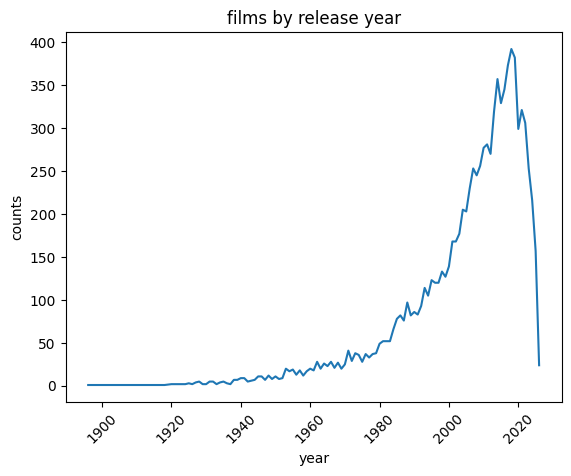

In [24]:
# distribution of film years 

year_counts=(df["release_year"].value_counts().sort_index().reset_index(name="counts"))
sns.lineplot(
    data=year_counts,x="release_year",y="counts"
)

plt.title("films by release year")
plt.xlabel("year")
plt.ylabel("counts")
plt.xticks(rotation=45)
plt.show()



In [25]:
year_counts.sort_values(by="counts",ascending=[False]).head(10)

,release_year,counts
103,2018,392
104,2019,382
102,2017,373
99,2014,357
101,2016,345
100,2015,329
106,2021,321
98,2013,319
107,2022,306
105,2020,299


In [26]:
year_counts.sort_values(by="counts",ascending=[False]).tail(10)

,release_year,counts
22,1937,2
6,1920,2
11,1926,2
18,1933,2
1,1902,1
0,1896,1
2,1903,1
3,1915,1
4,1916,1
5,1918,1


In [27]:
#distribution of adult films
adult_dist=(df["adult"].value_counts(normalize=True).reset_index())
adult_dist

,adult,proportion
0,False,1.0


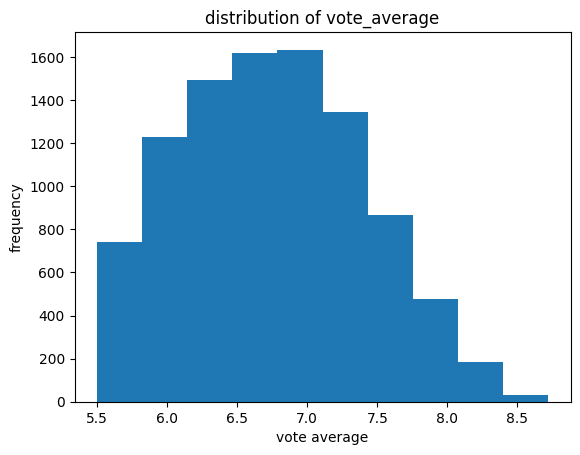

In [28]:
#distribution of vote_average

plt.hist(df["vote_average"])
plt.xlabel("vote average")
plt.ylabel("frequency")
plt.title("distribution of vote_average")
plt.show()

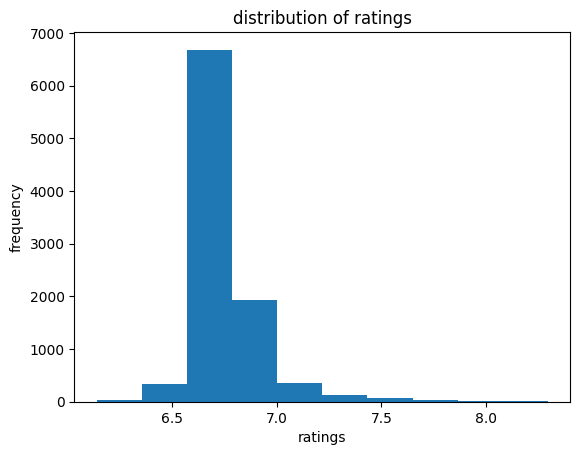

In [29]:
# distribution of weighted rating


plt.hist(df["weighted_rating"])
plt.xlabel("ratings")
plt.ylabel("frequency")
plt.title("distribution of ratings")
plt.show()

In [30]:
# top 20 films by weighted rating

rank=(df.sort_values(by="weighted_rating",ascending=False)
[["title","weighted_rating","vote_average","vote_count"]].head(20))
rank


,title,weighted_rating,vote_average,vote_count
8,The Shawshank Redemption,8.293767,8.718,30171
3,The Dark Knight,8.191639,8.528,35544
0,Interstellar,8.171289,8.470,39461
39,The Godfather,8.169397,8.686,22787
9,Pulp Fiction,8.108759,8.484,30036
6,Fight Club,8.089152,8.438,31844
10,Forrest Gump,8.088555,8.464,29575
1,Inception,8.087876,8.372,39061
20,The Lord of the Rings: The Return of the King,8.078067,8.496,26361
18,The Lord of the Rings: The Fellowship of the Ring,8.040677,8.432,27364


## TF-IDF


**Term Frequency (TF):** Measures how frequently a word appears in a movie's overview.

**Inverse Document Frequency (IDF):** Count the number of overviews in which the word appears at least once (not the total frequency of the word across all overviews)

cosine similarity: how similar two vectors are by the angle between them 

In [31]:
tfidf=TfidfVectorizer(stop_words="english",max_features=10000)#keeps the 10,000 most important words across moview overviews
tfidf_matrix=tfidf.fit_transform(df["overview"])

#cosine similarity
tfidf_sim=cosine_similarity(tfidf_matrix)

In [32]:
# tf-idf preserves the og index order

indices=pd.Series(df.index,index=df["title"])

def recommender(title: str,similarity_matrix: np.ndarray)->pd.DataFrame:
    idx=indices[title]
    
    sim_score=list(enumerate(similarity_matrix[idx]))
    ranked=sorted(sim_score,key=lambda x:x[1],reverse=True)
    
    movie_indices=[i[0] for i in ranked[0:11]]
    score=[i[1]for i in ranked[0:11]]
    
    recs=df.iloc[movie_indices][["title","weighted_rating"]]
    recs["similarity_score"]=score
    
    return recs

    

In [33]:
# test drama
recommender("The Shawshank Redemption",tfidf_sim)

,title,weighted_rating,similarity_score
8,The Shawshank Redemption,8.293767,1.000000
616,The 40 Year Old Virgin,6.593929,0.169607
6913,Brubaker,6.764285,0.155003
9227,Jawan,6.758025,0.150406
2107,Demolition,6.767249,0.149929
4734,One Shot,6.740373,0.143022
2928,A Prophet,6.886681,0.140548
882,Escape Plan,6.735251,0.139198
8101,Class of 1984,6.730838,0.130760
630,The Age of Adaline,7.077195,0.130569


In [34]:
# test thriller
recommender("Inception",tfidf_sim)


,title,weighted_rating,similarity_score
1,Inception,8.087876,1.000000
8956,Downrange,6.704314,0.170234
6714,New World,6.786145,0.166293
7552,Primeval,6.706925,0.153315
9340,Inception: The Cobol Job,6.763516,0.148362
7708,The Hunter's Prayer,6.688072,0.143998
4339,Possessor,6.704695,0.132030
8858,The Baytown Outlaws,6.713466,0.131562
532,Scream,7.078549,0.120469
6089,Cypher,6.736646,0.119377


In [35]:
# test kid's movie
recommender("Spirited Away",tfidf_sim)

,title,weighted_rating,similarity_score
95,Spirited Away,7.975041,1.000000
3133,Final Fantasy: The Spirits Within,6.656229,0.174335
8682,April and the Extraordinary World,6.759414,0.173045
8000,Straight Outta Nowhere: Scooby-Doo! Meets Cour...,6.789136,0.172620
2164,Horns,6.643350,0.168606
7564,What Maisie Knew,6.763608,0.167732
4692,Harriet,6.801454,0.163940
7160,The Last Mimzy,6.722922,0.158831
6607,Jin-Roh: The Wolf Brigade,6.785842,0.154974
8580,What's Love Got to Do with It,6.757564,0.153141


## Sentence Transformers

tf-idf doesnt accurately capture the semantic meaning of words(word_frequency vectors)
but sentence transofrmers represenet moves as semantic embeddings 




In [20]:
# Microsoft's minilm does not need gpu and most popular sentence transformer on hugging face
st_model=SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

st_matrix=st_model.encode(df["overview"].tolist(),show_progress_bar=True)

np.save(project_root/"models"/"embeddings.npy",st_matrix)

Batches: 100%|██████████| 301/301 [01:11<00:00,  4.20it/s]


In [ ]:
st_sim=cosine_similarity(st_matrix)

In [37]:
recommender("The Shawshank Redemption",st_sim)

,title,weighted_rating,similarity_score
8,The Shawshank Redemption,8.293767,1.000000
6339,Avengement,6.748096,0.540743
1850,Get Hard,6.558029,0.529544
2059,25th Hour,6.881209,0.522202
6241,In Hell,6.733835,0.515291
4054,Chaos,6.694124,0.514920
1522,Escape from New York,6.834569,0.512260
9227,Jawan,6.758025,0.494440
3472,The Boss,6.611124,0.490969
4770,Ruby & Quentin,6.739346,0.489639


In [38]:
recommender("Inception",st_sim)

,title,weighted_rating,similarity_score
1,Inception,8.087876,1.000000
1518,Identity Thief,6.478828,0.559091
8067,The Forger,6.702695,0.539326
9333,The Limits of Control,6.717641,0.521572
9380,The Spanish Prisoner,6.746819,0.510048
4884,Thick as Thieves,6.674392,0.508793
4750,Paranoia,6.644256,0.503484
6089,Cypher,6.736646,0.501206
6510,Antitrust,6.699652,0.498502
3599,The Zero Theorem,6.653032,0.497835


In [39]:
recommender("Spirited Away",st_sim)

,title,weighted_rating,similarity_score
95,Spirited Away,7.975041,1.000000
5375,White Bird in a Blizzard,6.696851,0.603258
3120,IF,6.780221,0.593861
5096,Roald Dahl's Matilda the Musical,6.749749,0.574842
1483,Insidious: Chapter 3,6.604483,0.574060
4777,The Glass Castle,6.780093,0.568163
6043,Godmothered,6.741639,0.558584
2325,The Nutcracker and the Four Realms,6.603765,0.556808
7144,Cuckoo,6.688509,0.549151
3513,Wolfwalkers,6.950012,0.545653


## Integrating TMDB API
- to get back recommendations

In [ ]:
def get_title(title: str)->dict:
    url="https://api.themoviedb.org/3/search/movie"
    params={
        "api_key":API_KEY,
        "query":title}
    response=requests.get(url,params=params)
    response.raise_for_status()
    
    return response.json() #converts json to python dict

In [41]:
response=get_title("Past Lives")
results=response["results"]

In [42]:
#create dropdown for users to select which movie specifically

for movie in results:
    print(movie['id'],movie['title'],movie['release_date'],movie['original_language'])

666277 Past Lives 2023-06-02 en
1001946 Past Lives 2022-07-16 en
881452 Past Lives  en
1078315 Past Lives  en
1164820 Past Lives 2023-03-02 tl
389170 The Past That Lives 1970-03-21 nl
38368 Uncle Boonmee Who Can Recall His Past Lives 2010-06-25 th
1020238 A Riddle from my past lives 2022-04-04 en


In [43]:
def select_movie(title: str):
    results=get_title(title)["results"]
    for i,movie in enumerate(results):
        year=movie.get("release_date",'Unknown')[:4]
        print(f"{i}:{movie["title"]}({year})")
    choice=int(input("select movie no.: "))
    return results[choice]

In [44]:
movie=select_movie('Past Lives')

0:Past Lives(2023)
1:Past Lives(2022)
2:Past Lives()
3:Past Lives()
4:Past Lives(2023)
5:The Past That Lives(1970)
6:Uncle Boonmee Who Can Recall His Past Lives(2010)
7:A Riddle from my past lives(2022)


select movie no.:  0


In [51]:
# after selecting the movie u want create the embedding for the overview


def recommend_new_movie(searched_movie):
    overview=searched_movie.get("overview","") #text preprocessing
    overview=re.sub(r'[^a-zA-Z\s]',"",overview.lower())

              
    query_embedding=st_model.encode([overview])
    
    scores=cosine_similarity(query_embedding,st_matrix)
    
    scores=scores.flatten() #frm 2d array to 1d array
    sim_scores=list(enumerate(scores))
    ranked=sorted(sim_scores,key=lambda x:x[1],reverse=True)

    movie_indices=[x[0] for x in ranked]
    similarity_scores = [x[1] for x in ranked]

    #get recommendations 
    recs=df.iloc[movie_indices][["id","title","weighted_rating","original_language"]].copy()

    recs["similarity_score"]=similarity_scores

    top_5_recs=recs[(recs["original_language"]!='en') & (recs["weighted_rating"]>=7.0)].head(5)
    
    return top_5_recs


    





In [52]:
foreign_film_recs=recommend_new_movie(movie)

,title,weighted_rating,original_language,similarity_score
1665,Incendies,7.126290,fr,0.384571
2026,Weathering with You,7.040791,ja,0.348727
95,Spirited Away,7.975041,ja,0.320595
1140,La Haine,7.217589,fr,0.314339
453,My Neighbor Totoro,7.422098,ja,0.310913


In [ ]:
# add  movie posters

def movie_details(movie_id: int):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}"

    params = {
        "api_key": API_KEY
    }

    response = requests.get(url, params=params)
    return response.json()

In [ ]:
def get_poster(movie_id: int):
    movie=movie_details(movie_id)
    poster_path=movie.get("poster_path")

    if poster_path is None:
        return None
        
    return "https://image.tmdb.org/t/p/w500"+poster_path

In [ ]:
foreign_film_recs["poster"]=foreign_film_recs["id"].apply(get_poster)